In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from multiprocessing import Pool


import torch
import torch.nn as nn
import torch.nn.functional as F
import gc
import random
from cosine_annealing_warmup import CosineAnnealingWarmupRestarts as CAWR
from sklearn.linear_model import LinearRegression
from multiprocessing import Pool

In [3]:
def get_signal(signal_path,L_CUT = 0, U_CUT = 0):

    f = open(f"{DATA_PATH}/{signal}", "r")
    data = f.readlines()
    f.close()
    ################################################################################################
    
    ################################################################################################
    y = np.array(list(map(lambda x: abs(float(x.split("\t")[-1].split("\n")[0])), data)), dtype=float)
    x = np.array(list(map(lambda x: float(x.split("\t")[0].split("\n")[0]), data)), dtype=float)
    max_x = x.max()
    idx = (x>=L_CUT) * (x<=(max_x-U_CUT))
    
    x = x[idx]
    y = y[idx]
    return x,y

def get_surface(x,y):
    alpha = np.arange(0.5, 1.5, 0.001)
    beta = np.arange(0.5, 1.5, 0.001)
    a, b = np.meshgrid(alpha, beta)    
    
    Z = np.zeros_like(a)
    log_y = np.log(y)
    for i in tqdm(range(a.shape[0])):
        for j in range(a.shape[1]):
            t1 = np.exp(-1*a[i,j]*x[:,None])
            t2 = np.exp(-1*b[i,j]*x[:,None])
            X = np.concatenate([t1,t2],-1)
            reg = LinearRegression(fit_intercept=False).fit(X, y)
            pred_y = reg.predict(X)
            if (pred_y < 0 ).any():
                Z[i,j] = None
            else:
                Z[i,j] = np.mean((log_y - np.log(pred_y))**2)

    return Z,a,b

In [4]:
signal = 'B0_st'
DATA_PATH = "../CorrelatorStudy/Bdata/ext_file"


In [5]:
x,y = get_signal(signal_path=DATA_PATH,
                 L_CUT=0,
                 U_CUT=0)
Z,a,b = get_surface(x = x,y = y)

  0%|          | 0/1000 [00:00<?, ?it/s]

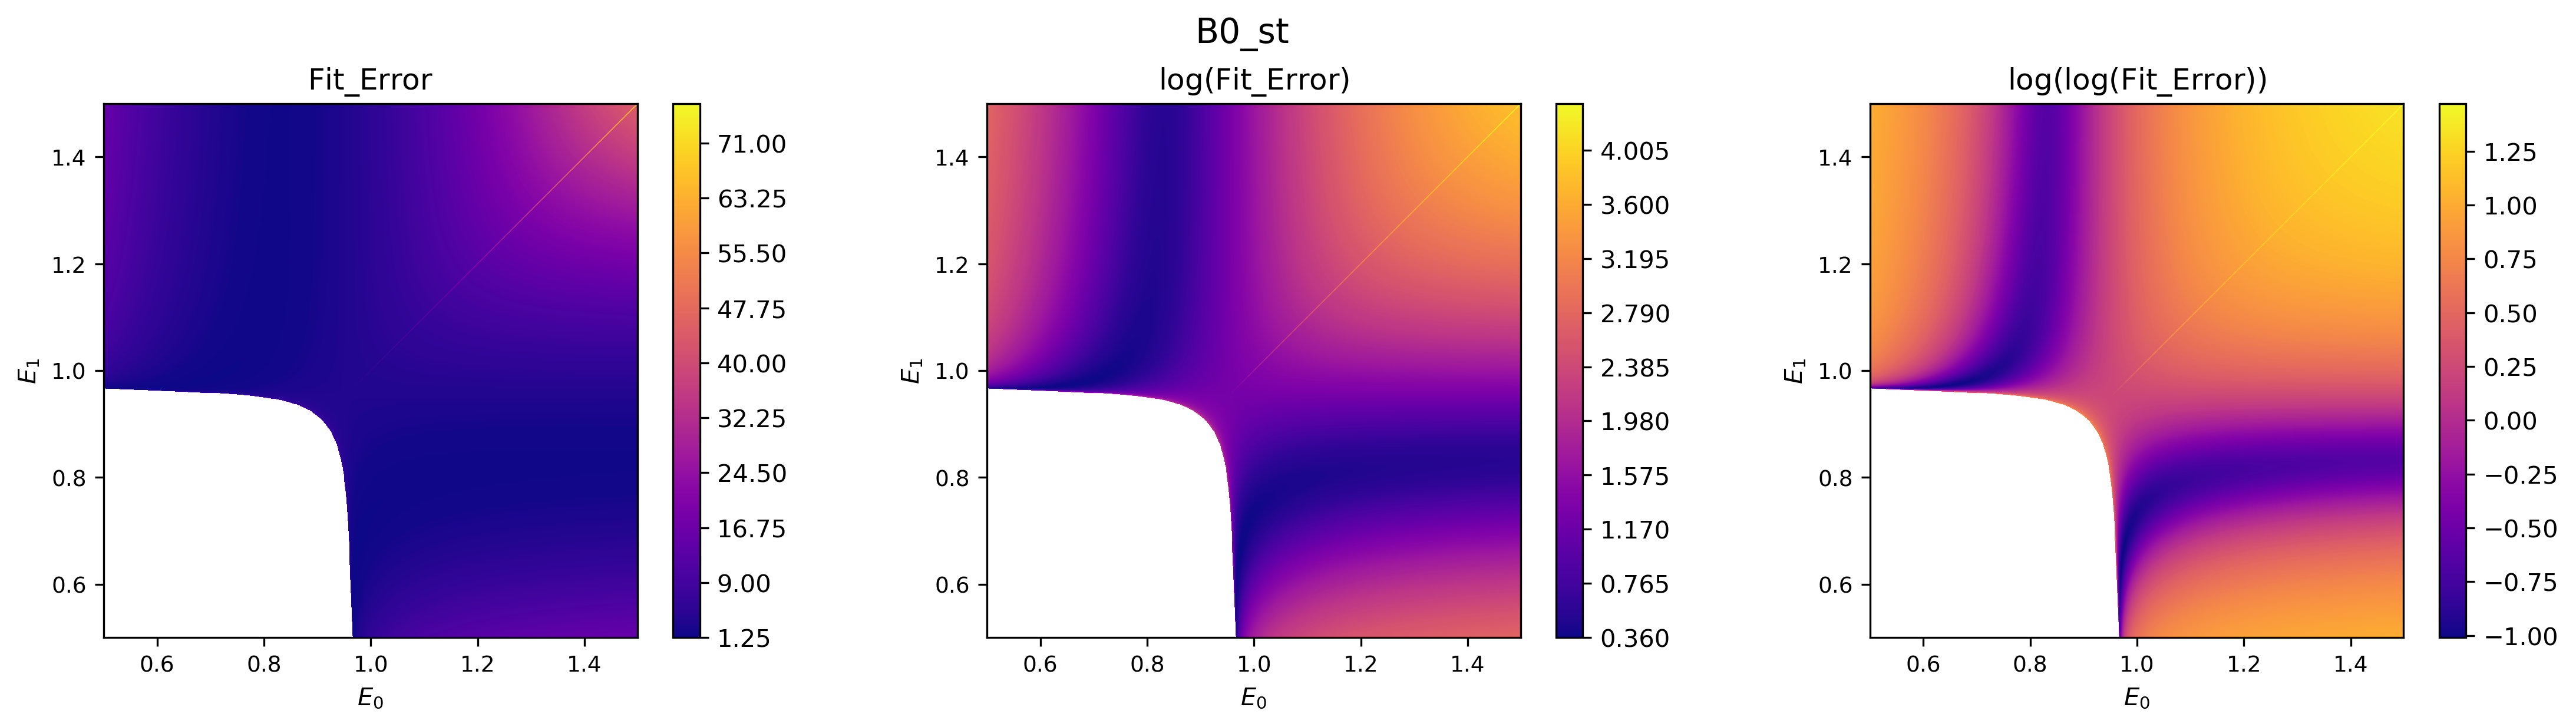

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True,dpi=300)

im1 = axes[0].contourf(a, b, Z, levels=300, cmap='plasma')
fig.colorbar(im1, ax=axes[0])
axes[0].set_title(r"$\text{Fit_Error}$", fontsize=12)
axes[0].set_xlabel(r"$E_0$")
axes[0].set_ylabel(r"$E_1$")

Z_log = np.log(Z)
im2 = axes[1].contourf(a, b, Z_log, levels=300, cmap='plasma')
fig.colorbar(im2, ax=axes[1])
axes[1].set_title(r"$\log(\text{Fit_Error})$", fontsize=12)
axes[1].set_xlabel(r"$E_0$")
axes[1].set_ylabel(r"$E_1$")

Z_loglog = np.log(np.log(Z))
im3 = axes[2].contourf(a, b, Z_loglog, levels=300, cmap='plasma')
fig.colorbar(im3, ax=axes[2])
axes[2].set_title(r"$\log(\log(\text{Fit_Error}))$", fontsize=12)
axes[2].set_xlabel(r"$E_0$")
axes[2].set_ylabel(r"$E_1$")

for ax in axes:
    ax.tick_params(labelsize=9)
    ax.set_aspect('equal')  # keeps scale consistent
    ax.set_facecolor('white')

plt.suptitle("B0_st", fontsize=14)
plt.savefig("./store/surface_plot.png", dpi=300, bbox_inches='tight')

plt.show()